In [1]:
import pandas as pd

df = pd.read_csv('/content/Air_Quality.csv')

print('First 5 rows of the DataFrame:')
print(df.head())

print('\nConcise summary of the DataFrame:')
df.info()

print('\nDescriptive statistics of the DataFrame:')
print(df.describe())

First 5 rows of the DataFrame:
  Unique ID Indicator ID                    Name Measure Measure Info  \
0    336867          375  Nitrogen dioxide (NO2)    Mean          ppb   
1    336741          375  Nitrogen dioxide (NO2)    Mean          ppb   
2    550157          375  Nitrogen dioxide (NO2)    Mean          ppb   
3    412802          375  Nitrogen dioxide (NO2)    Mean          ppb   
4    412803          375  Nitrogen dioxide (NO2)    Mean          ppb   

  Geo Type Name Geo Join ID                     Geo Place Name  \
0            CD         407      Flushing and Whitestone (CD7)   
1            CD         107              Upper West Side (CD7)   
2            CD         414  Rockaway and Broad Channel (CD14)   
3            CD         407      Flushing and Whitestone (CD7)   
4            CD         407      Flushing and Whitestone (CD7)   

           Time Period  Start_Date  Data Value  Message  
0       Winter 2014-15  12-01-2014       23.97      NaN  
1       Winter 20

In [2]:
from sklearn.preprocessing import StandardScaler

# 1. Drop the 'Message' column
df = df.drop('Message', axis=1)
print("Dropped 'Message' column.")

# 2. Convert the 'Start_Date' column to datetime objects
df['Start_Date'] = pd.to_datetime(df['Start_Date'], errors='coerce')
print("Converted 'Start_Date' to datetime.")

# 3. Extract 'Year' and 'Month' components
df['Year'] = df['Start_Date'].dt.year.astype('Int64') # Use 'Int64' to allow NaN
df['Month'] = df['Start_Date'].dt.month.astype('Int64') # Use 'Int64' to allow NaN
print("Extracted 'Year' and 'Month' from 'Start_Date'.")

# 4. Drop the original 'Start_Date' column
df = df.drop('Start_Date', axis=1)
print("Dropped original 'Start_Date' column.")

# 5. Drop any rows that still contain missing values
df.dropna(inplace=True)
print("Dropped rows with any remaining missing values.")

# 6. Identify numerical columns for normalization
numerical_cols = ['Data Value', 'Year', 'Month']

# 7. & 8. Instantiate a StandardScaler object
scaler = StandardScaler()

# 9. Apply the StandardScaler to the identified numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
print(f"Normalized columns: {numerical_cols}.")

# 11. Display the first 5 rows and a concise summary of the updated DataFrame
print('\nFirst 5 rows of the updated DataFrame:')
print(df.head())

print('\nConcise summary of the updated DataFrame:')
df.info()

Dropped 'Message' column.
Converted 'Start_Date' to datetime.
Extracted 'Year' and 'Month' from 'Start_Date'.
Dropped original 'Start_Date' column.
Dropped rows with any remaining missing values.
Normalized columns: ['Data Value', 'Year', 'Month'].

First 5 rows of the updated DataFrame:
  Unique ID Indicator ID                    Name Measure Measure Info  \
0    336867          375  Nitrogen dioxide (NO2)    Mean          ppb   
1    336741          375  Nitrogen dioxide (NO2)    Mean          ppb   
2    550157          375  Nitrogen dioxide (NO2)    Mean          ppb   
3    412802          375  Nitrogen dioxide (NO2)    Mean          ppb   
4    412803          375  Nitrogen dioxide (NO2)    Mean          ppb   

  Geo Type Name Geo Join ID                     Geo Place Name  \
0            CD         407      Flushing and Whitestone (CD7)   
1            CD         107              Upper West Side (CD7)   
2            CD         414  Rockaway and Broad Channel (CD14)   
3       

Selected numerical features for anomaly detection.
DBSCAN model instantiated.
DBSCAN model fitted and clusters predicted.
Added 'Anomaly' column to the DataFrame.


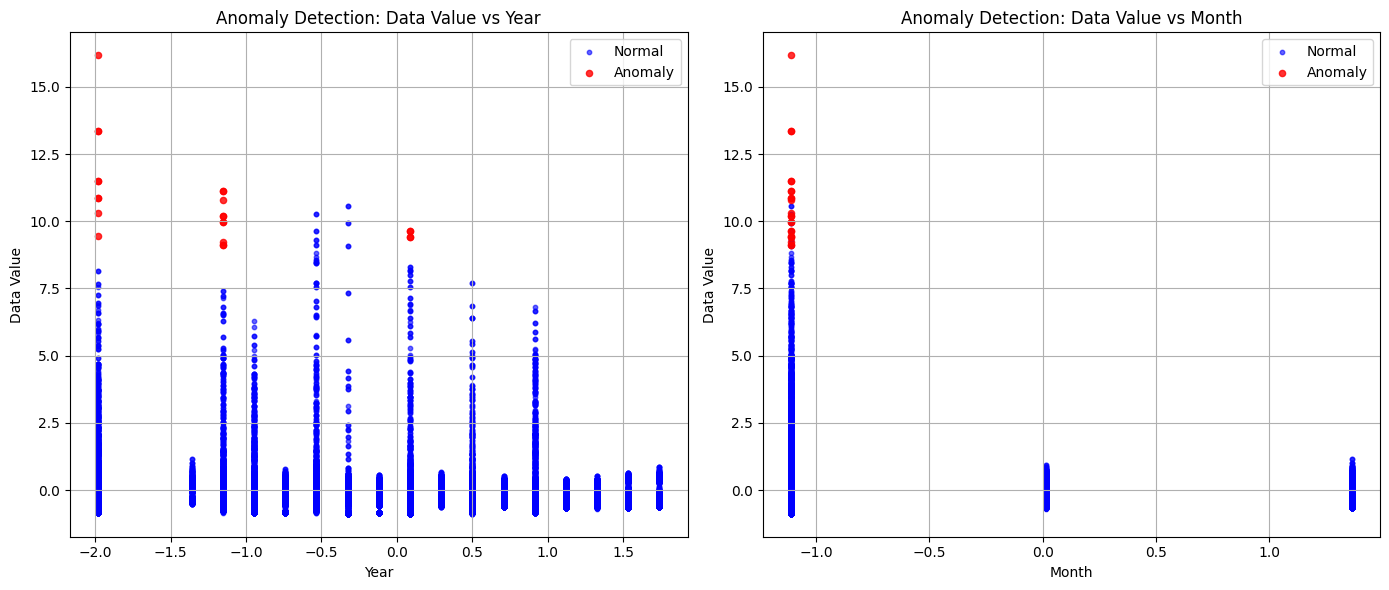


First 5 rows of the DataFrame with Anomaly column:
  Unique ID Indicator ID                    Name Measure Measure Info  \
0    336867          375  Nitrogen dioxide (NO2)    Mean          ppb   
1    336741          375  Nitrogen dioxide (NO2)    Mean          ppb   
2    550157          375  Nitrogen dioxide (NO2)    Mean          ppb   
3    412802          375  Nitrogen dioxide (NO2)    Mean          ppb   
4    412803          375  Nitrogen dioxide (NO2)    Mean          ppb   

  Geo Type Name Geo Join ID                     Geo Place Name  \
0            CD         407      Flushing and Whitestone (CD7)   
1            CD         107              Upper West Side (CD7)   
2            CD         414  Rockaway and Broad Channel (CD14)   
3            CD         407      Flushing and Whitestone (CD7)   
4            CD         407      Flushing and Whitestone (CD7)   

           Time Period  Data Value      Year     Month Anomaly  
0       Winter 2014-15    0.079249 -0.119860  1

In [3]:
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Select the numerical features 'Data Value', 'Year', and 'Month'
numerical_features_for_anomaly = df[numerical_cols].copy()
print("Selected numerical features for anomaly detection.")

# 2. & 3. Instantiate a DBSCAN object
dbscan = DBSCAN(eps=0.5, min_samples=5)
print("DBSCAN model instantiated.")

# 4. Fit the DBSCAN model and predict cluster labels
clusters = dbscan.fit_predict(numerical_features_for_anomaly)
print("DBSCAN model fitted and clusters predicted.")

# 5. Add a new column named 'Anomaly' to the original DataFrame `df`
df['Anomaly'] = np.where(clusters == -1, 'Anomaly', 'Normal')
print("Added 'Anomaly' column to the DataFrame.")

# 6. Visualize the identified anomalies using 2D scatter plots

plt.figure(figsize=(14, 6))

# Data Value vs Year
plt.subplot(1, 2, 1)
plt.scatter(df['Year'][df['Anomaly'] == 'Normal'], df['Data Value'][df['Anomaly'] == 'Normal'],
            c='blue', label='Normal', s=10, alpha=0.6)
plt.scatter(df['Year'][df['Anomaly'] == 'Anomaly'], df['Data Value'][df['Anomaly'] == 'Anomaly'],
            c='red', label='Anomaly', s=20, alpha=0.8)
plt.xlabel('Year')
plt.ylabel('Data Value')
plt.title('Anomaly Detection: Data Value vs Year')
plt.legend()
plt.grid(True)

# Data Value vs Month
plt.subplot(1, 2, 2)
plt.scatter(df['Month'][df['Anomaly'] == 'Normal'], df['Data Value'][df['Anomaly'] == 'Normal'],
            c='blue', label='Normal', s=10, alpha=0.6)
plt.scatter(df['Month'][df['Anomaly'] == 'Anomaly'], df['Data Value'][df['Anomaly'] == 'Anomaly'],
            c='red', label='Anomaly', s=20, alpha=0.8)
plt.xlabel('Month')
plt.ylabel('Data Value')
plt.title('Anomaly Detection: Data Value vs Month')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print('\nFirst 5 rows of the DataFrame with Anomaly column:')
print(df.head())

In [4]:
import numpy as np

# 1. Calculate the 33rd and 67th percentiles of the 'Data Value' column
low_threshold = df['Data Value'].quantile(0.33)
high_threshold = df['Data Value'].quantile(0.67)

print(f"Low threshold (33rd percentile): {low_threshold:.2f}")
print(f"High threshold (67th percentile): {high_threshold:.2f}")

# 2. & 3. Create a new column 'Pollution_Category' based on thresholds
def create_pollution_category(data_value):
    if data_value <= low_threshold:
        return 'Low'
    elif data_value <= high_threshold:
        return 'Moderate'
    else:
        return 'High'

df['Pollution_Category'] = df['Data Value'].apply(create_pollution_category)

# 4. Display the count of each category in the 'Pollution_Category' column
print('\nCount of each Pollution Category:')
print(df['Pollution_Category'].value_counts())

# 5. Display the first 5 rows of the DataFrame with the new 'Pollution_Category' column
print('\nFirst 5 rows of the DataFrame with Pollution_Category:')
print(df.head())

Low threshold (33rd percentile): -0.48
High threshold (67th percentile): 0.07

Count of each Pollution Category:
Pollution_Category
Moderate    9631
Low         9353
High        9350
Name: count, dtype: int64

First 5 rows of the DataFrame with Pollution_Category:
  Unique ID Indicator ID                    Name Measure Measure Info  \
0    336867          375  Nitrogen dioxide (NO2)    Mean          ppb   
1    336741          375  Nitrogen dioxide (NO2)    Mean          ppb   
2    550157          375  Nitrogen dioxide (NO2)    Mean          ppb   
3    412802          375  Nitrogen dioxide (NO2)    Mean          ppb   
4    412803          375  Nitrogen dioxide (NO2)    Mean          ppb   

  Geo Type Name Geo Join ID                     Geo Place Name  \
0            CD         407      Flushing and Whitestone (CD7)   
1            CD         107              Upper West Side (CD7)   
2            CD         414  Rockaway and Broad Channel (CD14)   
3            CD         407     

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# 1. Identify the feature columns (X) and the target column (y)
# Exclude specified columns from features
exclude_cols = ['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
                'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
                'Anomaly', 'Pollution_Category']

X = df.drop(columns=exclude_cols)
y = df['Pollution_Category']

print(f"Feature columns (X): {X.columns.tolist()}")
print(f"Target column (y) shape: {y.shape}")

# Handle categorical features in X by one-hot encoding
X = pd.get_dummies(X, drop_first=True)
print(f"Feature columns after one-hot encoding (X.shape): {X.shape}")

# 2. Encode the categorical target variable 'Pollution_Category' into numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Target variable encoded into numerical labels. Classes: {label_encoder.classes_}")

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print(f"Data split into training (X_train shape: {X_train.shape}, y_train shape: {y_train.shape}) and testing (X_test shape: {X_test.shape}, y_test shape: {y_test.shape}) sets.")

# 4. Train a Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)
print('Decision Tree Classifier trained successfully.')

# 5. Train an XGBoost Classifier
xgboost_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgboost_model.fit(X_train, y_train)
print('XGBoost Classifier trained successfully.')

# 6. Train a Neural Network Classifier
# Increase max_iter if convergence warning appears
neural_network_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, verbose=False)
neural_network_model.fit(X_train, y_train)
print('Neural Network Classifier trained successfully.')

Feature columns (X): ['Data Value', 'Year', 'Month']
Target column (y) shape: (28334,)
Feature columns after one-hot encoding (X.shape): (28334, 3)
Target variable encoded into numerical labels. Classes: ['High' 'Low' 'Moderate']
Data split into training (X_train shape: (22667, 3), y_train shape: (22667,)) and testing (X_test shape: (5667, 3), y_test shape: (5667,)) sets.
Decision Tree Classifier trained successfully.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:22:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier trained successfully.
Neural Network Classifier trained successfully.


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# 1. Identify the feature columns (X) and the target column (y)
# Exclude specified columns from features
exclude_cols = ['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
                'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
                'Anomaly', 'Pollution_Category']

X = df.drop(columns=exclude_cols)
y = df['Pollution_Category']

print(f"Feature columns (X): {X.columns.tolist()}")
print(f"Target column (y) shape: {y.shape}")

# Handle categorical features in X by one-hot encoding
X = pd.get_dummies(X, drop_first=True)
print(f"Feature columns after one-hot encoding (X.shape): {X.shape}")

# 2. Encode the categorical target variable 'Pollution_Category' into numerical labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(f"Target variable encoded into numerical labels. Classes: {label_encoder.classes_}")

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)
print(f"Data split into training (X_train shape: {X_train.shape}, y_train shape: {y_train.shape}) and testing (X_test shape: {X_test.shape}, y_test shape: {y_test.shape}) sets.")

# 4. Train a Decision Tree Classifier
decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)
print('Decision Tree Classifier trained successfully.')

# 5. Train an XGBoost Classifier
xgboost_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgboost_model.fit(X_train, y_train)
print('XGBoost Classifier trained successfully.')

# 6. Train a Neural Network Classifier
# Increase max_iter if convergence warning appears
neural_network_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, verbose=False)
neural_network_model.fit(X_train, y_train)
print('Neural Network Classifier trained successfully.')

Feature columns (X): ['Data Value', 'Year', 'Month']
Target column (y) shape: (28334,)
Feature columns after one-hot encoding (X.shape): (28334, 3)
Target variable encoded into numerical labels. Classes: ['High' 'Low' 'Moderate']
Data split into training (X_train shape: (22667, 3), y_train shape: (22667,)) and testing (X_test shape: (5667, 3), y_test shape: (5667,)) sets.
Decision Tree Classifier trained successfully.
XGBoost Classifier trained successfully.
Neural Network Classifier trained successfully.



--- Evaluating Decision Tree ---
Accuracy: 1.0000
F1-score (macro): 1.0000


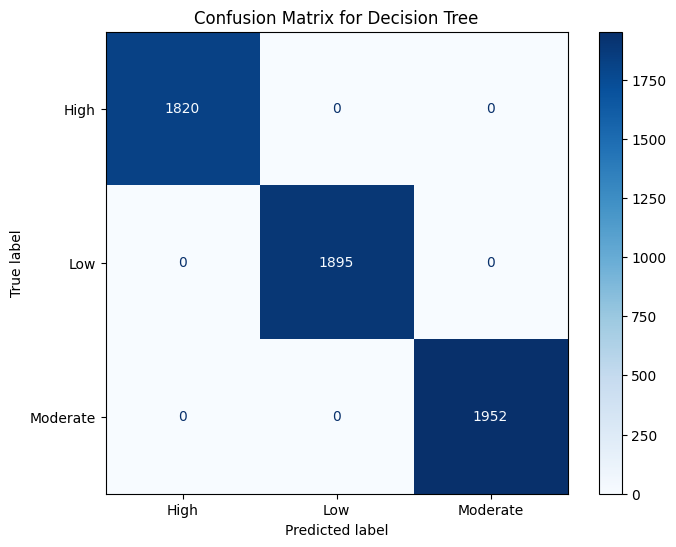


--- Evaluating XGBoost ---
Accuracy: 0.9995
F1-score (macro): 0.9995


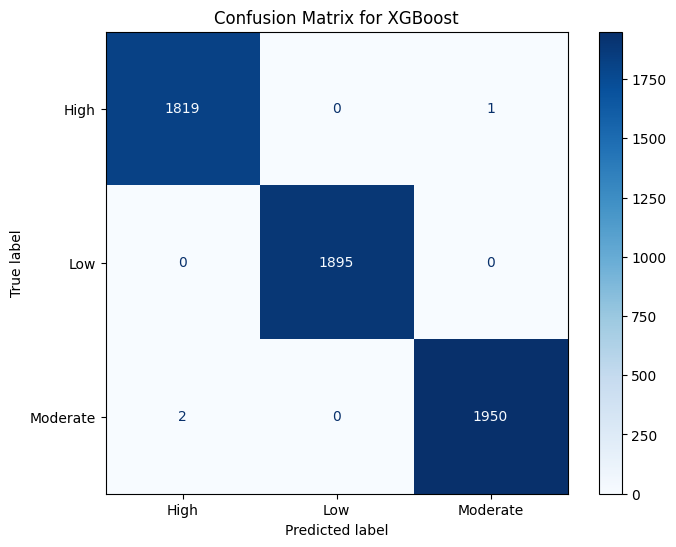


--- Evaluating Neural Network ---
Accuracy: 0.9966
F1-score (macro): 0.9967


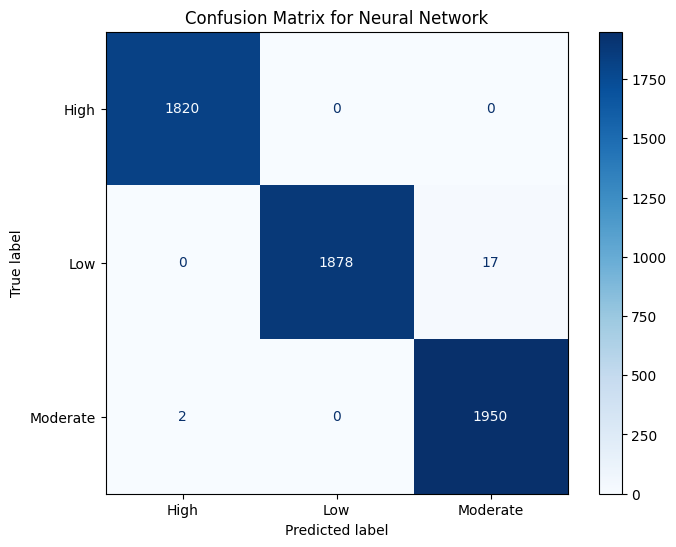

In [7]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models = {
    'Decision Tree': decision_tree_model,
    'XGBoost': xgboost_model,
    'Neural Network': neural_network_model
}

# Get class labels from label_encoder (already fitted)
class_labels = label_encoder.classes_

for name, model in models.items():
    print(f'\n--- Evaluating {name} ---')
    # 2a. Make predictions on the test set
    y_pred = model.predict(X_test)

    # 2b. Calculate and print accuracy score
    accuracy = accuracy_score(y_test, y_pred)
    print(f'Accuracy: {accuracy:.4f}')

    # 2c. Calculate and print F1-score
    f1 = f1_score(y_test, y_pred, average='macro')
    print(f'F1-score (macro): {f1:.4f}')

    # 2d. Compute the confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # 2e. Create a ConfusionMatrixDisplay object
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

    # 2f. Plot the confusion matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'Confusion Matrix for {name}')
    plt.show()


DataFrame without anomalies created. New shape: (28311, 14)
Feature columns (X_no_anomaly) prepared. Shape: (28311, 3)
Target variable (y_no_anomaly) encoded. Shape: (28311,)
Data split into training and testing sets (without anomalies).
Decision Tree Classifier (without anomalies) trained successfully.
XGBoost Classifier (without anomalies) trained successfully.
Neural Network Classifier (without anomalies) trained successfully.

--- Evaluating Decision Tree (No Anomaly) ---
Accuracy: 1.0000
F1-score (macro): 1.0000


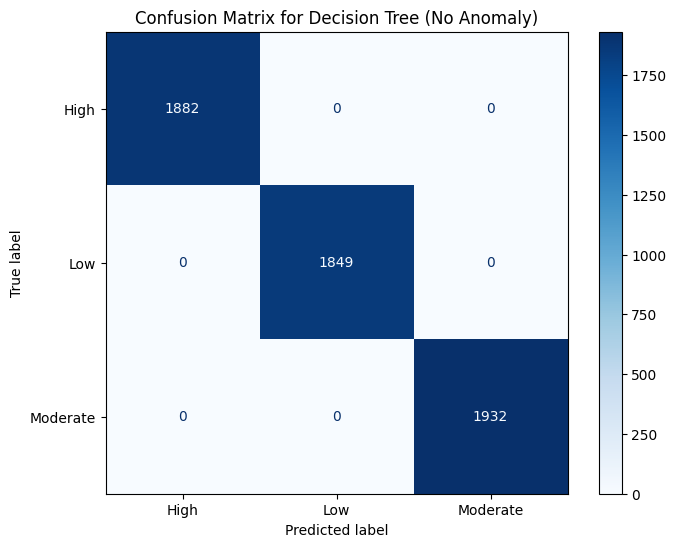


--- Evaluating XGBoost (No Anomaly) ---
Accuracy: 0.9982
F1-score (macro): 0.9982


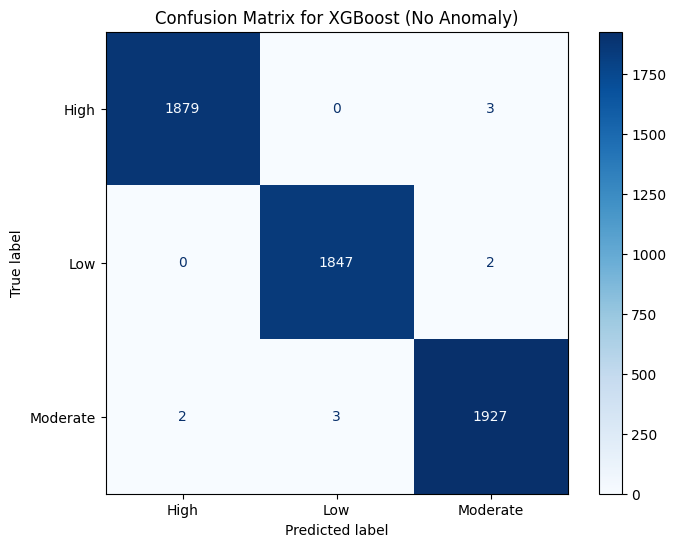


--- Evaluating Neural Network (No Anomaly) ---
Accuracy: 0.9993
F1-score (macro): 0.9993


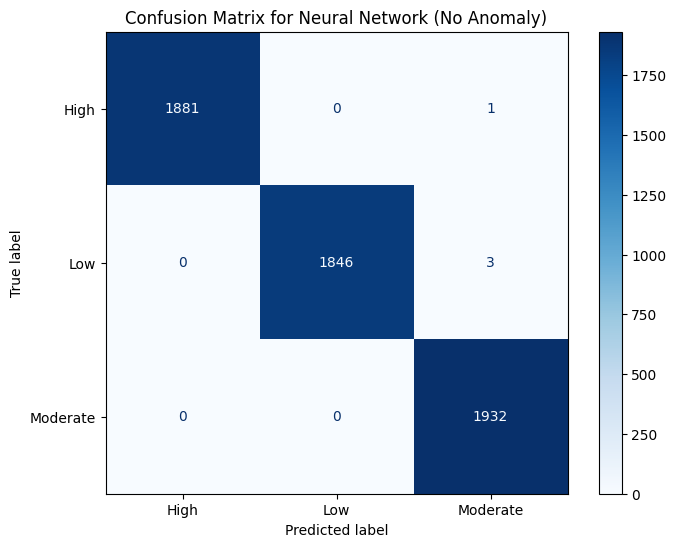

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Create a new DataFrame, df_no_anomaly, by filtering the original DataFrame df
df_no_no_anomaly = df[df['Anomaly'] == 'Normal'].copy()
print(f"DataFrame without anomalies created. New shape: {df_no_no_anomaly.shape}")

# 2. Define the feature set X_no_anomaly and handle categorical features
# Exclude specified columns from features, similar to the previous step
exclude_cols = ['Unique ID', 'Indicator ID', 'Name', 'Measure', 'Measure Info',
                'Geo Type Name', 'Geo Join ID', 'Geo Place Name', 'Time Period',
                'Anomaly', 'Pollution_Category']

X_no_no_anomaly = df_no_no_anomaly.drop(columns=exclude_cols)
# One-hot encoding for categorical features (though in this case 'Data Value', 'Year', 'Month' are already numerical)
X_no_no_anomaly = pd.get_dummies(X_no_no_anomaly, drop_first=True)
print(f"Feature columns (X_no_anomaly) prepared. Shape: {X_no_no_anomaly.shape}")

# 3. Define the target variable y_no_anomaly and encode it
y_no_no_anomaly = df_no_no_anomaly['Pollution_Category']
y_encoded_no_no_anomaly = label_encoder.transform(y_no_no_anomaly) # Use already fitted label_encoder
print(f"Target variable (y_no_anomaly) encoded. Shape: {y_encoded_no_no_anomaly.shape}")

# 4. Split X_no_anomaly and y_no_anomaly into new training and testing sets
X_train_no_anomaly, X_test_no_anomaly, y_train_no_anomaly, y_test_no_anomaly = train_test_split(
    X_no_no_anomaly, y_encoded_no_no_anomaly, test_size=0.2, random_state=42)
print("Data split into training and testing sets (without anomalies).")

# Initialize dictionaries to store models and their performance for comparison
models_no_anomaly = {}

# 5. Initialize and train new instances of Decision Tree, XGBoost, and MLPClassifier

# Decision Tree
decision_tree_model_no_anomaly = DecisionTreeClassifier(random_state=42)
decision_tree_model_no_anomaly.fit(X_train_no_anomaly, y_train_no_anomaly)
models_no_anomaly['Decision Tree (No Anomaly)'] = decision_tree_model_no_anomaly
print('Decision Tree Classifier (without anomalies) trained successfully.')

# XGBoost
xgboost_model_no_anomaly = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgboost_model_no_anomaly.fit(X_train_no_anomaly, y_train_no_anomaly)
models_no_anomaly['XGBoost (No Anomaly)'] = xgboost_model_no_anomaly
print('XGBoost Classifier (without anomalies) trained successfully.')

# Neural Network
neural_network_model_no_anomaly = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42, verbose=False)
neural_network_model_no_anomaly.fit(X_train_no_anomaly, y_train_no_anomaly)
models_no_anomaly['Neural Network (No Anomaly)'] = neural_network_model_no_anomaly
print('Neural Network Classifier (without anomalies) trained successfully.')

# 6. & 7. Evaluate and visualize performance for each retrained model
for name, model in models_no_anomaly.items():
    print(f'\n--- Evaluating {name} ---')
    y_pred_no_anomaly = model.predict(X_test_no_anomaly)

    accuracy = accuracy_score(y_test_no_anomaly, y_pred_no_anomaly)
    print(f'Accuracy: {accuracy:.4f}')

    f1 = f1_score(y_test_no_anomaly, y_pred_no_anomaly, average='macro')
    print(f'F1-score (macro): {f1:.4f}')

    cm = confusion_matrix(y_test_no_anomaly, y_pred_no_anomaly)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    ax.set_title(f'Confusion Matrix for {name}')
    plt.show()

# 8. Comparison (summary, done in markdown after this step)